In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("E-Commerce/raw_ecommerce_sales.csv")
print("Shape:",df.shape)

Shape: (3500, 7)


In [3]:
print("\nColumns:",df.columns)


Columns: Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')


In [4]:
print("\nData Types:\n",df.dtypes)
print("\nMissing Values:\n",df.isnull().sum())


Data Types:
 Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

Missing Values:
 Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64


In [5]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.dtypes

Order Date      datetime64[ns]
Product Name            object
Category                object
Region                  object
Quantity                 int64
Sales                    int64
Profit                 float64
dtype: object

In [7]:
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df["Month Name"]=df["Order Date"].dt.month_name()

df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Month Name
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024,12,December
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022,11,November
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022,5,May
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024,3,March
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022,9,September


In [8]:
df[df["Profit"]<0].head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Month Name


In [9]:
print("Minimum Profit:", df["Profit"].min())

Minimum Profit: 6.97


In [10]:
print("Maximum Profit:", df["Profit"].max())

Maximum Profit: 2946.93


In [11]:
## Calculated Fields

In [12]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

In [13]:
profit_margin=(total_profit/total_sales)*100
print("Overall Profit Margin: {: .2f}%".format(profit_margin))

Overall Profit Margin:  17.29%


In [14]:
## Sales & Profit by region

In [15]:
regional_sales_profit=df.groupby("Region")[["Sales","Profit"]].sum()
regional_sales_profit

,Sales,Profit
Region,,
East,2675110,464888.46
North,2488773,426314.75
South,2659548,458103.27
West,2844450,495358.73


In [16]:
df["Year"].unique()

array([2024, 2022, 2023], dtype=int32)

In [17]:
## Sales and Profit by Year

In [18]:
yearly_sales_profit = df.groupby("Year")[["Sales","Profit"]].sum()
yearly_sales_profit

,Sales,Profit
Year,,
2022,3255970,572856.98
2023,3786592,666866.42
2024,3625319,604941.81


In [19]:
## Sales And Profit by Category

In [20]:
category_sales_profit = df.groupby("Category")[["Sales","Profit"]].sum()
category_sales_profit

,Sales,Profit
Category,,
Accessories,4247591,736084.74
Electronics,5326074,923185.59
Office,1094216,185394.88


In [21]:
## Top 10 Products

In [22]:
top_products= df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Monitor       1876
Smartwatch    1807
Camera        1795
Mouse         1753
Printer       1734
Tablet        1733
Keyboard      1684
Laptop        1658
Smartphone    1617
Headphones    1604
Name: Quantity, dtype: int64

In [23]:
## Data Visualizations

In [24]:
sns.set_style("whitegrid")

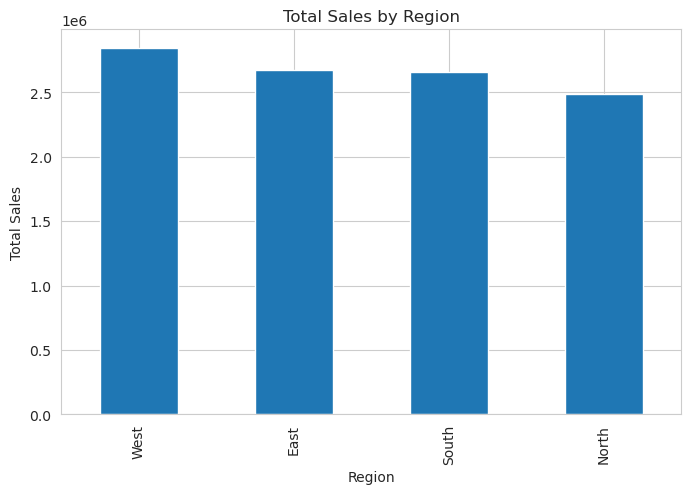

In [25]:
## Sales by Region

sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

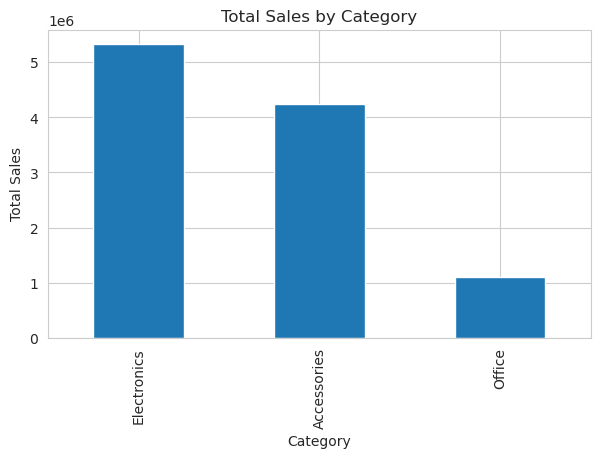

In [26]:
## Sales by Category

sales_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sales_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [27]:
print(df.columns)

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit', 'Year', 'Month', 'Month Name'],
      dtype='object')


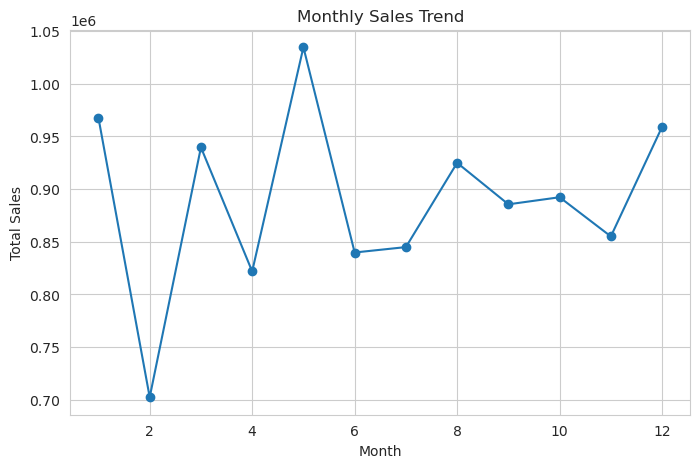

In [28]:
## Monthly Sales Trend
sales_month = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_month.plot(kind="line",marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

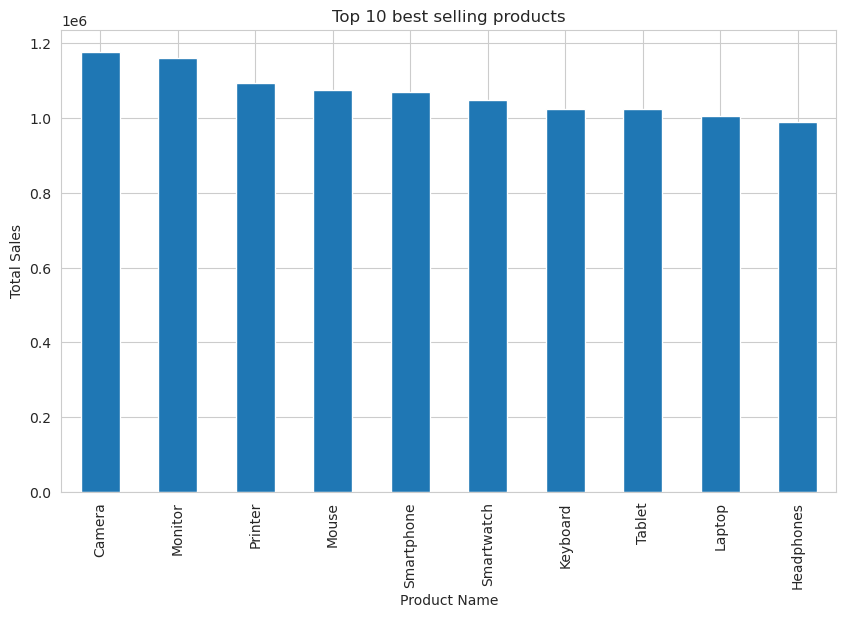

In [29]:
## Top 10 products
top_products= df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")

plt.title("Top 10 best selling products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

plt.show()

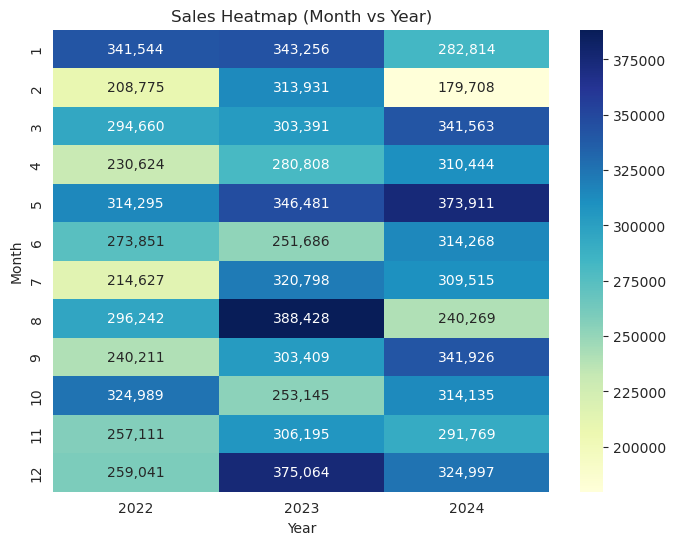

In [33]:
# Sales Heatmap (Month vs Year)
sales_heatmap=df.pivot_table(
    values="Sales",
    index="Month",
    columns="Year",
    aggfunc="sum"
)
plt.figure(figsize=(8,6))
sns.heatmap(sales_heatmap,annot=True,fmt=",.0f",cmap="YlGnBu")

plt.title("Sales Heatmap (Month vs Year)")
plt.xlabel("Year")
plt.ylabel("Month")

plt.show()

In [34]:
## Advanced EDA

In [35]:
## Profit Margin by Category (finding - Profits are consistent across categories)

<Axes: title={'center': 'Average Profit Margin by Category'}, xlabel='Category'>

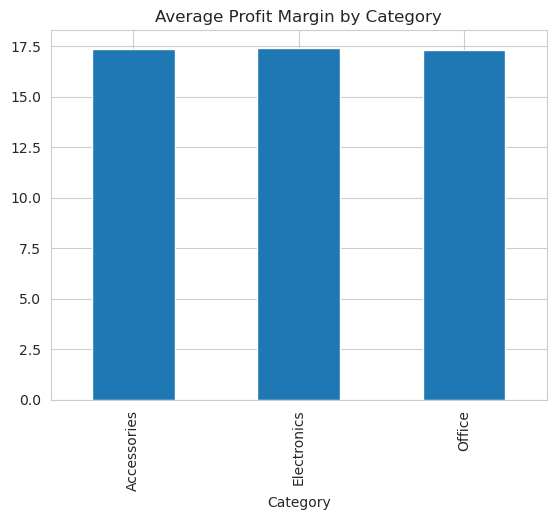

In [37]:
df["profit_margin"]=(df["Profit"]/df["Sales"])*100
margin_category=df.groupby("Category")["profit_margin"].mean()
margin_category.plot(kind="bar",title="Average Profit Margin by Category")

In [38]:
## Correlation Analysis (Relationship between Variables)

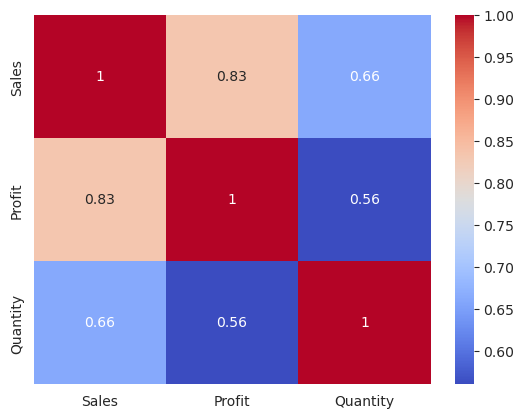

In [39]:
corr=df[["Sales","Profit","Quantity"]].corr()
sns.heatmap(corr, annot=True,cmap="coolwarm")
plt.show()

In [40]:
## Scatter Plot Analysis

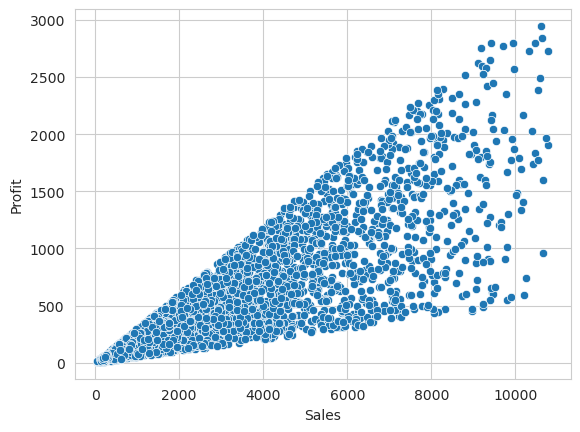

In [41]:
sns.scatterplot(data=df, x="Sales",y="Profit")
plt.title="Sales vs Profit relationship"
plt.show()

In [42]:
### 1. There are almost no points where high sales have very low profit compared to the rest of the dataset. This is called a positive correlation.
### 2. ALL points appear above the horizontal axis where Profit = 0. There are no Loss-making transactions in this dataset.
### 3. The vertical spread of points shows the range of profit for the same sales value. Higher value transactions show greater profit variability.
### 4. When many points cluster in one region of the chart, it indicates: The majority of transactions fall within a moderate sales range.

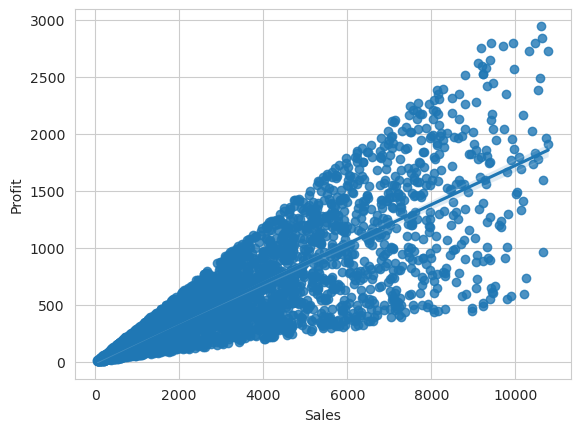

In [43]:
sns.regplot(data=df,x="Sales",y="Profit")
plt.title="Sales vs profit Trend"
plt.show()

In [44]:
## Distribution Analysis

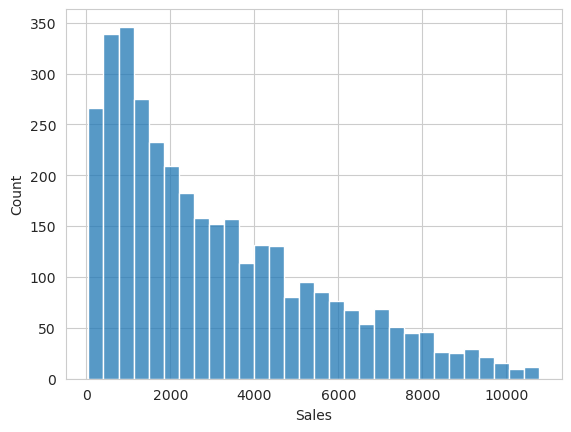

In [45]:
sns.histplot(df["Sales"], bins =30)
plt.title="Sales Distribution"
plt.show()

In [46]:
## Box Plot (Outlier Detection)

<function matplotlib.pyplot.show(close=None, block=None)>

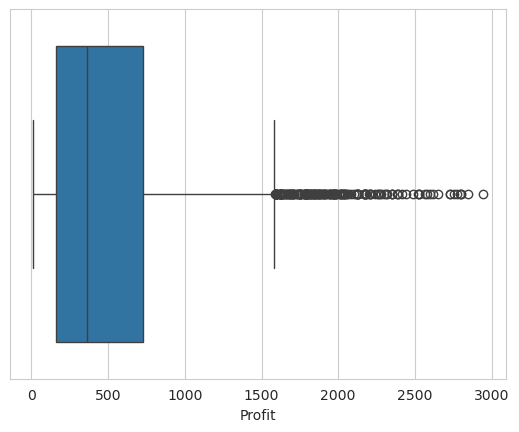

In [47]:
sns.boxplot(x=df["Profit"])
plt.title="Profit Outliers"
plt.show

In [48]:
## Pair Plot

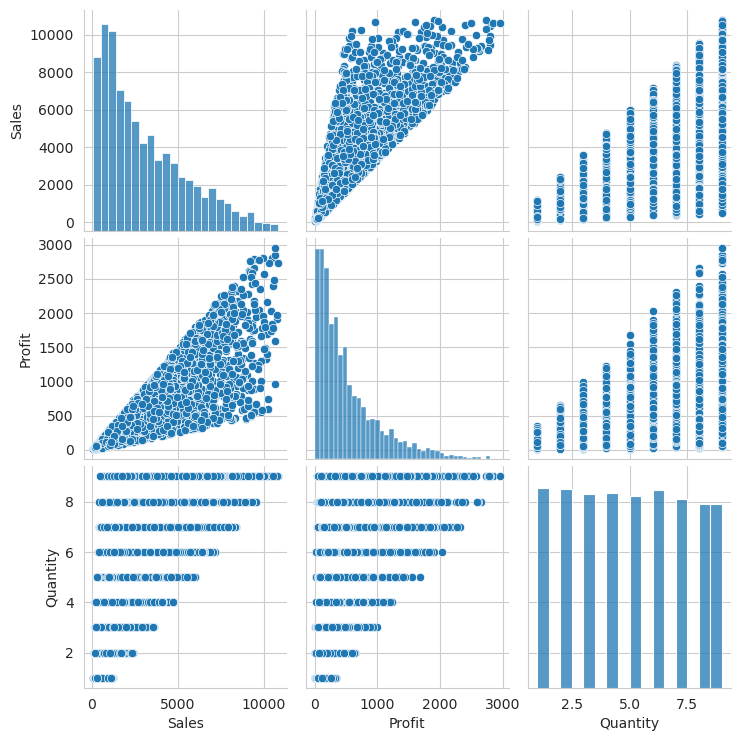

In [49]:
sns.pairplot(df[["Sales","Profit","Quantity"]])
plt.show()